In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits

In [ ]:
#example = fits.open('/dat/milic/MiHi_Fe_I_plage/obs04/mihi_sp/lr0250/img_fit.102000..107999.00.00.lr0250.cube.fits')

In [ ]:
#example.info()

Filename: /dat/milic/MiHi_Fe_I_plage/obs04/mihi_sp/lr0250/img_fit.102000..107999.00.00.lr0250.cube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   (588, 4, 160, 147)   float32   
  1                1 ImageHDU         7   (588,)   float64   
  2                1 ImageHDU         8   (160, 147)   float32   


In [7]:
example[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    4 / number of data axes                            
NAXIS1  =                  588 / length of data axis 1                          
NAXIS2  =                    4 / length of data axis 2                          
NAXIS3  =                  160 / length of data axis 3                          
NAXIS4  =                  147 / length of data axis 4                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2024-03-12'         / Creation UTC (CCCC-MM-DD) date of FITS header  
NSR     =                    1 /                                                
WLI1    =                   

In [2]:
cube = fits.open('/dat/milic/MiHI_Na_I_plage/plage/obs01/mihi_sp/lr0500/cubeseries_Na_cori.fits')[0].data

In [3]:
cube.shape

(961, 124, 136, 2, 440)

In [4]:
# In order of appearence: time, x, y, Stokes component and wavelength

# Jan said it's these ones: 
t = 790
i = 45
j = 35

In [5]:
mean_spec_test = np.mean(cube[100,:,:,0,:],axis=(0,1))

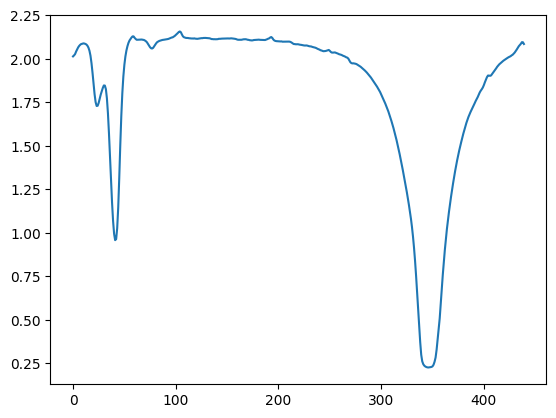

In [20]:
plt.plot(mean_spec_test)
#plt.xlim([30,50])

In [7]:
lmin = 120
lmax = 160

In [27]:
I_cont_cube = np.mean(cube[:,:,:,0,lmin:lmax],axis=3)
I_full_band_cube = np.mean(cube[:,:,:,0,:],axis=3)
I_lw_cube = np.mean(cube[:,:,:,0,330:350],axis=3)
I_ni_cube = np.mean(cube[:,:,:,0,35:38],axis=3)

I_qs = np.mean(I_cont_cube,axis=(1,2))

In [26]:
# Stokes V:
V_lw_cube = np.mean(cube[:,:,:,1,330:350],axis=3)
V_ni_cube = np.mean(cube[:,:,:,1,32:40],axis=3)

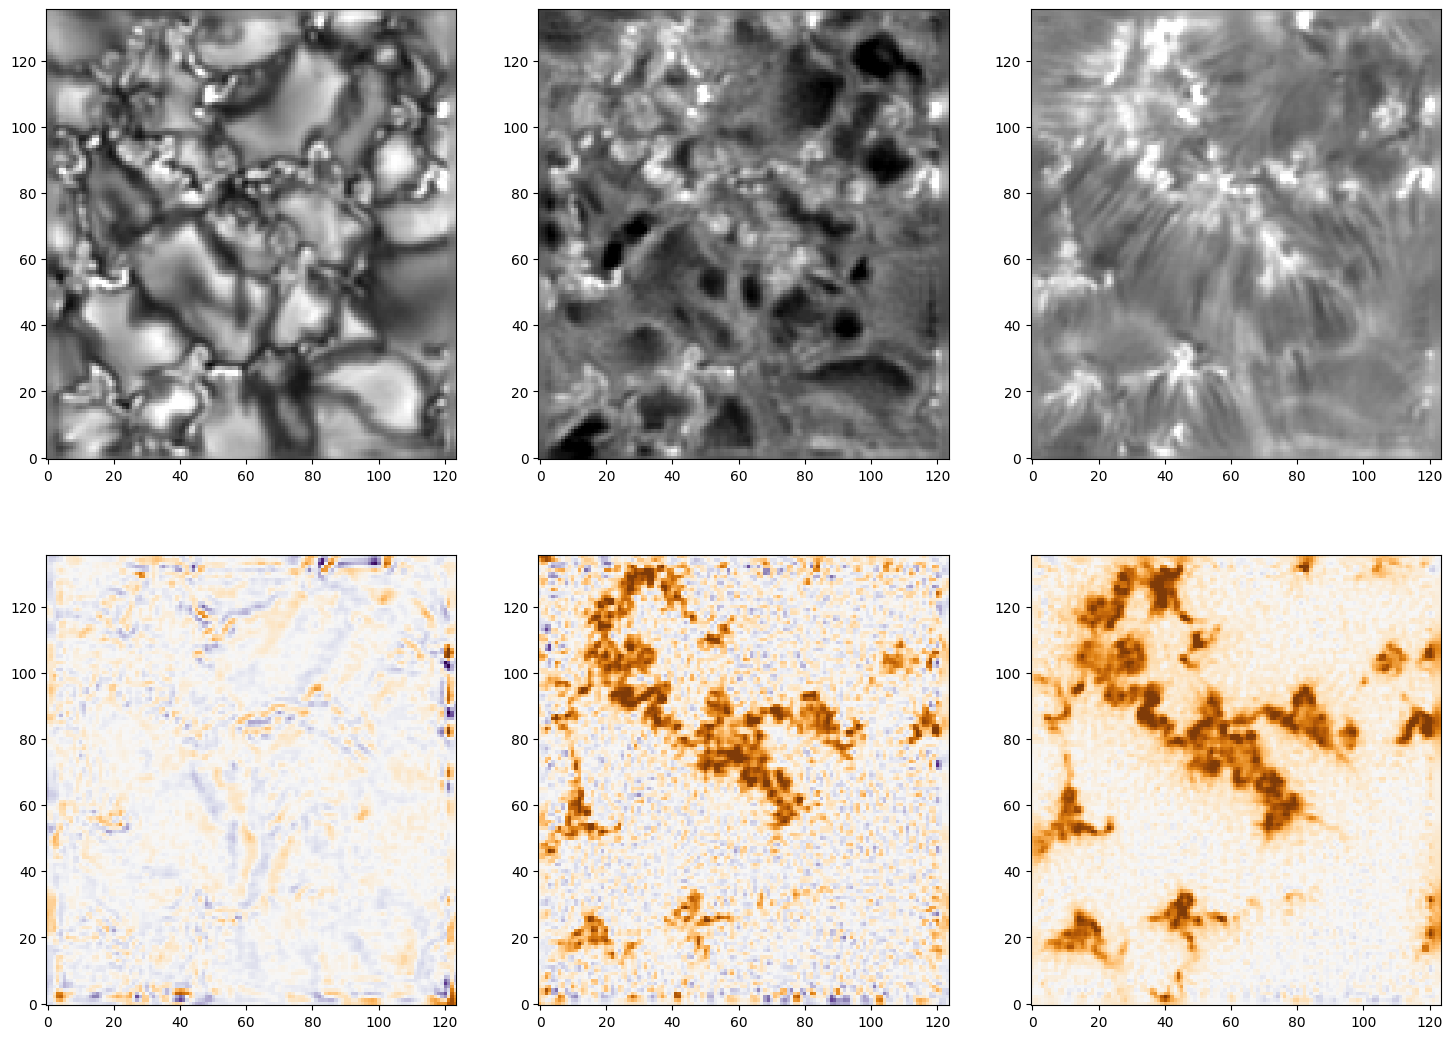

In [29]:
# We can plot the Stokes I image:
t = 90
plt.figure(figsize=(18,13))
plt.subplot(231)
plt.imshow(I_cont_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.7, vmax=1.3)
#plt.colorbar()
plt.subplot(232)
plt.imshow(I_ni_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.4, vmax=1.1)
#plt.colorbar()
plt.subplot(233)
plt.imshow(I_lw_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.05, vmax=0.35)
#plt.colorbar()

plt.subplot(234)
plt.imshow(I_cont_cube[t,:,:].T/I_qs[t] -I_cont_cube[t-1,:,:].T/I_qs[t-1] , origin='lower', cmap='PuOr', vmin=-0.1, vmax=0.1)
#plt.colorbar()
plt.subplot(235)
plt.imshow(V_ni_cube[t,:,:].T/I_qs[t], origin='lower', cmap = 'PuOr', vmin=-0.07, vmax=0.07)
#plt.imshow(I_ni_cube[t,:,:].T/I_qs[t] - I_ni_cube[t-1,:,:].T/I_qs[t-1], origin='lower', cmap='PuOr', vmin=-0.1, vmax=0.1)
#plt.colorbar()
plt.subplot(236)
plt.imshow(V_lw_cube[t,:,:].T/I_qs[t], origin='lower', cmap = 'PuOr', vmin=-0.05, vmax=0.05)
#plt.imshow(I_lw_cube[t,:,:].T/I_qs[t] - I_lw_cube[t-1,:,:].T/I_qs[t-1], origin='lower', cmap='PuOr', vmin=-0.05, vmax=0.05)

#plt.colorbar()

#plt.colorbar()

In [12]:
I_cut = np.mean(I_cont_cube[:,108:113,:], axis=1)
I_cut.shape



(961, 136)

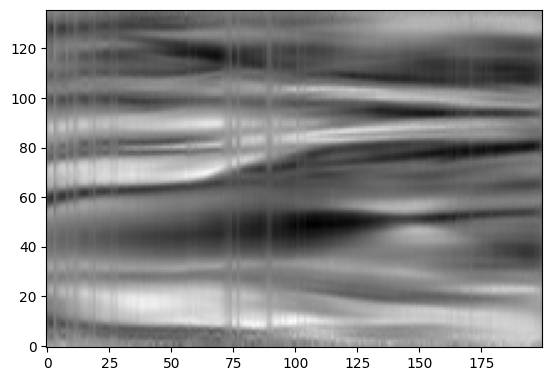

In [13]:
plt.imshow(I_cut[50:250,:].T, origin='lower', cmap='gray')
    

In [52]:
# Calculate speed real quick:
print(20*50 / 45 / 2.7)



8.23045267489712


In [18]:
from tqdm import tqdm

In [ ]:
# seems like it's there, let's dump series of figures to make a video: 
path = '/scratch/milic/mihinavideo/'
for t in tqdm(range(1, 961)):
    plt.figure(figsize=(18,13))
    
    plt.subplot(231)
    plt.imshow(I_cont_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.7, vmax=1.3)
    # Add the text with time, max 4 digits total:
    plt.text(10, 10, f'Time: {t*2.7:.2f} s', color='white', fontsize=12, backgroundcolor='black')
    #plt.colorbar()
    plt.subplot(232)
    plt.imshow(I_ni_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.4, vmax=1.1)
    #plt.colorbar()
    plt.subplot(233)
    plt.imshow(I_lw_cube[t,:,:].T/I_qs[t], origin='lower', cmap='gray', vmin=0.05, vmax=0.35)
    #plt.colorbar()

    plt.subplot(234)
    plt.imshow(I_cont_cube[t,:,:].T/I_qs[t] -I_cont_cube[t-1,:,:].T/I_qs[t-1] , origin='lower', cmap='PuOr', vmin=-0.1, vmax=0.1)
    #plt.colorbar()
    plt.subplot(235)
    plt.imshow(V_ni_cube[t,:,:].T/I_qs[t], origin='lower', cmap = 'PuOr', vmin=-0.07, vmax=0.07)
    #plt.imshow(I_ni_cube[t,:,:].T/I_qs[t] - I_ni_cube[t-1,:,:].T/I_qs[t-1], origin='lower', cmap='PuOr', vmin=-0.1, vmax=0.1)
    #plt.colorbar()
    plt.subplot(236)
    plt.imshow(V_lw_cube[t,:,:].T/I_qs[t], origin='lower', cmap = 'PuOr', vmin=-0.05, vmax=0.05)
    #plt.imshow(I_lw_cube[t,:,:].T/I_qs[t] - I_lw_cube[t-1,:,:].T/I_qs[t-1], origin='lower', cmap='PuOr', vmin=-0.05, vmax=0.05)

    plt.savefig(path + f'{(t-1):04d}.png', bbox_inches='tight')
    plt.close()

100%|██████████| 960/960 [13:43<00:00,  1.17it/s]


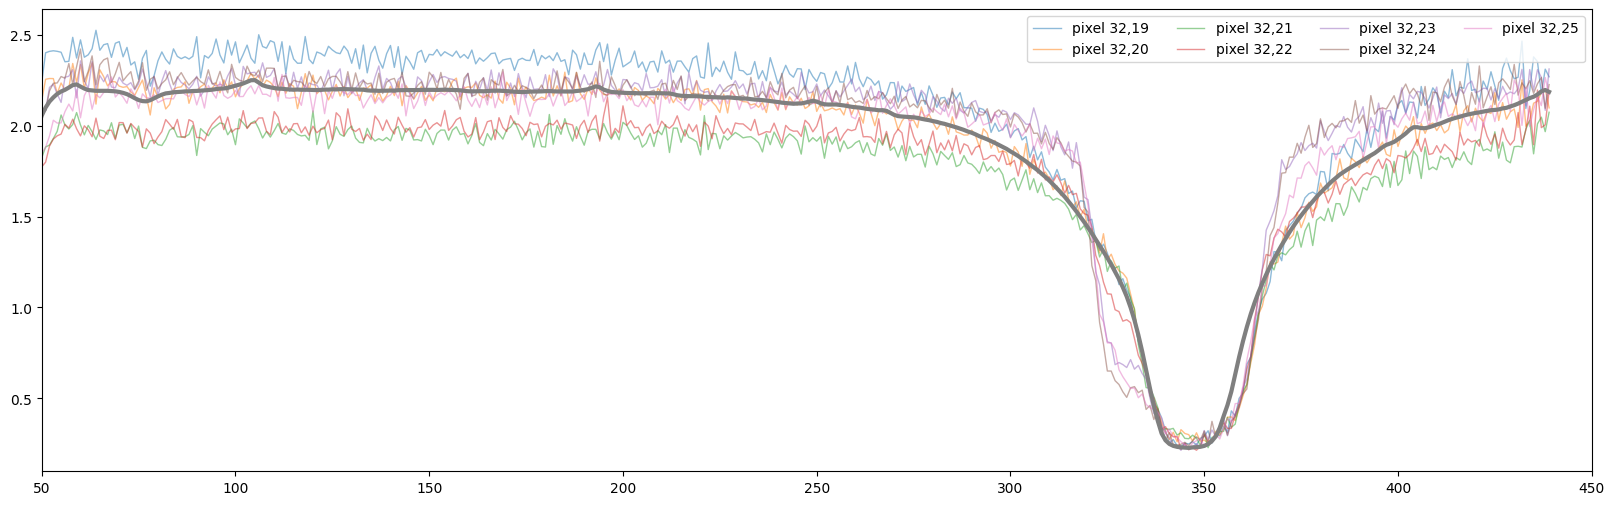

In [9]:
plt.figure(figsize=(20,6))

i = 32
j = 22

deltai = 0
deltaj = 3
for ii in range(-deltai, deltai+1):
    for jj in range(-deltaj, deltaj+1):
        plt.plot(cube[t, i+ii, j+jj, 0, :], linewidth=1.0, alpha=0.5, label='pixel '+str(i+ii)+','+str(j+jj))
#plt.plot(cube[t, j-12, i-12, 0, :])
plt.plot(mean_I_t_dependent[t, 0, :], linewidth=3.0)
plt.xlim([50, 450])
plt.legend(ncol=4, loc ='upper right')

In [ ]:
# Integrate that interesting wing and plot only negative values: 
I_bw = np.sum(cube[:,:,:,0,321:331]/cube[:,:,:,0,190:200]-\
    mean_I_t_dependent[:,None,None,0,321:331]/mean_I_t_dependent[:,None,None,0,190:200],axis=-1)
#I_bw[I_bw > 0] = 0


In [10]:
I_qs = np.mean(cube[t,:,:,0,200:220])
print (I_qs)

2.1734116


In [11]:
cube /= I_qs

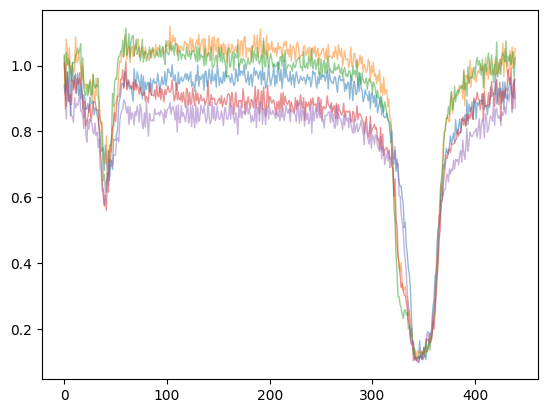

In [14]:
j = 24
for i in range(30,35):
    plt.plot(cube[t, i, j, 0, :], linewidth=1.0, alpha=0.5, label='pixel '+str(i)+','+str(j))

In [ ]:
stokes_for_tanausu = cube[t, 30:35, 22:27, 0, :]
print(stokes_for_tanausu.shape)

(5, 5, 440)


In [19]:
ll = fits.open('/dat/milic/MiHI_Na_I_plage/plage/obs01/mihi_sp/lr0500/cubeseries_Na_cori.fits')[1].data
ll.shape

kek = fits.PrimaryHDU(stokes_for_tanausu)
bur = fits.ImageHDU(ll)
lol = fits.HDUList([kek, bur])
lol.writeto('/dat/milic/MiHI_Na_I_plage/cubeseries_Na_mihi_tanausu.fits', overwrite=True)

(35.0, 65.0)

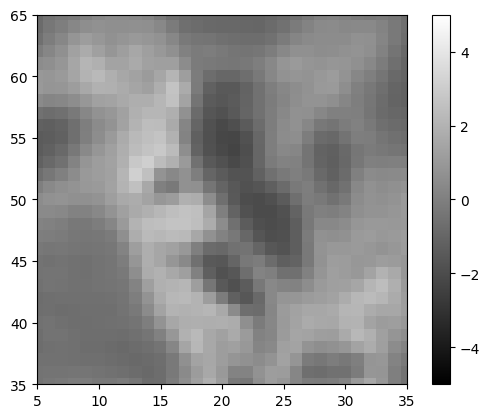

In [87]:
plt.imshow(I_bw[t,:,:].T,vmin=-5,vmax=5,origin='lower', cmap='gray')
plt.colorbar()
plt.xlim([5,35])
plt.ylim([35,65])

(250.0, 380.0)

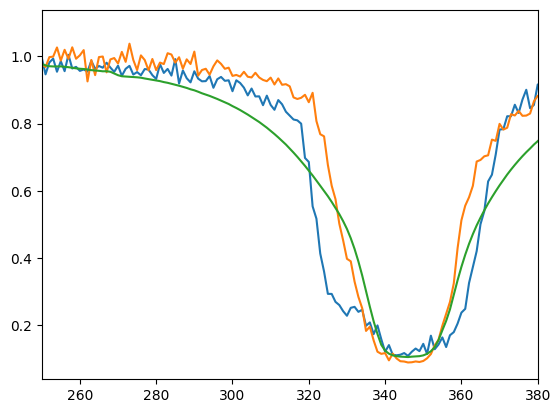

In [88]:
plt.plot(cube[t,32,24,0,:]/cube[t,32,24,0,200])
plt.plot(cube[t,15,52,0,:]/cube[t,15,52,0,200])
plt.plot(mean_I_t_dependent[t,0,:]/mean_I_t_dependent[t,0,200])
plt.xlim([250,380])


In [90]:
contrast_profile = (cube[:,:,:,0,:] - mean_I_t_dependent[:,None,None,0,:]) / mean_I_t_dependent[:,None,None,0,:]

(250.0, 380.0)

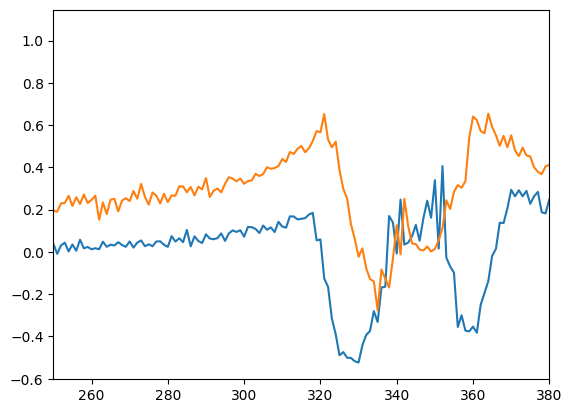

In [92]:
plt.plot(contrast_profile[t,32,24,:])
plt.plot(contrast_profile[t,15,52,:])
plt.xlim([250,380])

(20.0, 40.0)

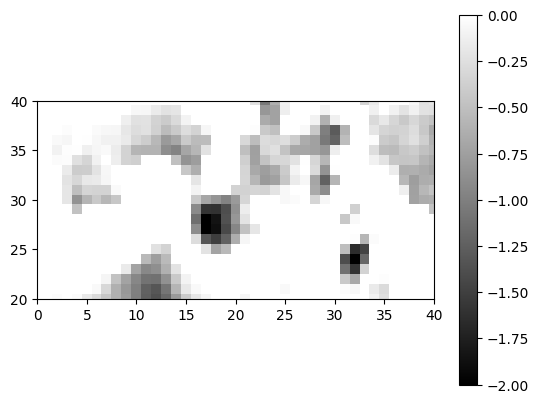

In [97]:
contrast_total = np.sum(contrast_profile[:,:,:,323:328], axis=-1)
plt.imshow(contrast_total[t,:,:].T, origin='lower', cmap='gray',vmin=-2, vmax=0)
plt.colorbar()
plt.xlim([0,40])
plt.ylim([20,40])

(250.0, 380.0)

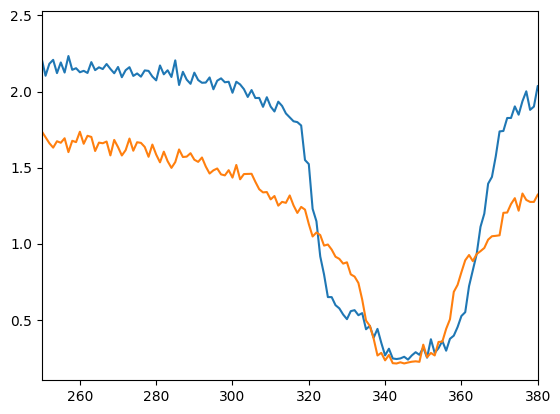

In [100]:
plt.plot(cube[t,32,24,0,:])
plt.plot(cube[t,16,28,0,:])
#plt.plot(mean_I_t_dependent[t,0,:]/mean_I_t_dependent[t,0,200])
plt.xlim([250,380])
